# Step 2: Pb isotope classification

In [1]:
xf = "206Pb_207Pb_mean"
yf = "208Pb_207Pb_mean"
xerr = xf.replace("mean", "2SE")
yerr = yf.replace("mean", "2SE")

In [2]:
import pandas as pd
import numpy as np

Load the preprocessing scaler and the classification model fitted in the Pb clustering [notebook](<1 Pb clustering.ipynb>):

In [ ]:
import sciris as sc

scaler = sc.load("Pb_RobustScaler.obj")
gmm = sc.load("Pb_GMM.obj")

## Load & preprocess data

In [4]:
raw_data = pd.read_csv("data/tbl-S2-Pb-results.csv")

In [5]:
full_data_mask = (raw_data[xerr] < 0.003) & (raw_data[yerr] < 0.004)
print("data remaining after filtering:", round(sum(full_data_mask) / len(raw_data) * 100, 2), "%")

data remaining after filtering: 96.58 %


In [6]:
full_data = raw_data.copy().loc[full_data_mask]
X_full_unscaled = full_data.loc[:, [xf, yf]].to_numpy(dtype=np.float32)
X_full_index = full_data.loc[full_data_mask, "spot_id"]

### Normalise the data

In [7]:
X_full_scaled = scaler.transform(X_full_unscaled)

## Classify full data

Use a likelihood cutoff to avoid spurious clustering of outliers.

First, work out a reasonable threshold. This is based on a [gist](https://gist.github.com/keatonb/e18dfe66d29779e6eb95fcdd585cb2f8) by Keaton Bell

In [8]:
stepsize = 0.01
x_g = np.arange(-10, 10, stepsize)
y_g = np.arange(-10, 10, stepsize)
X_grid, Y_grid = np.meshgrid(x_g, y_g)
XX_grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z_grid = -gmm.score_samples(XX_grid)
Z_grid = Z_grid.reshape(X_grid.shape)

Check: numerical integration over whole sampled region should give 1 (to within numerical precision)

In [9]:
np.sum(np.exp(-Z_grid)) * stepsize**2

1.000000000000043

In [10]:
pvalue = 0.001

# Do this by sorting lnL high to low and matching to cumulative sum,
# then interpolate to desired value.

sortlnL = np.sort(-Z_grid.flatten())[::-1]
cumsum = np.cumsum(np.exp(sortlnL) * stepsize**2)

# Make interpolator
from scipy.interpolate import interp1d

lnLatpvalue = interp1d(1 - cumsum, sortlnL)

log_prob_min = lnLatpvalue(pvalue)
print(
    f'{(1-pvalue)*100:.1f}% of the GMM has a log-likelihood of > {log_prob_min:.3f}. Use as the threshold for a "confidence interval".'
)

99.9% of the GMM has a log-likelihood of > -7.756. Use as the threshold for a "confidence interval".


Classify all the data, and then assign -1 (unclassified) to any points with a log-likelihood below the threshold:

In [11]:
groups = gmm.predict(X_full_scaled)
log_probs = gmm.score_samples(X_full_scaled)

In [12]:
groups = np.where(
    log_probs > log_prob_min, groups, -1
)

cluster_mapping = {
    "-1": "X",
    "0": "D",
    "1": "A",
    "2": "C",
    "3": "B",
    "4": "E",
}

# add index back to cluster matrix
groups = pd.Series(groups, index=X_full_index, name="groups_new")

full_data = full_data.join(groups, on="spot_id")
full_data["group"] = full_data["groups_new"].fillna(-1).astype("int32")
full_data.drop(columns=["groups_new"], inplace=True)
full_data["group"] = full_data.group.astype(str).map(cluster_mapping)

### Plot the classified full data

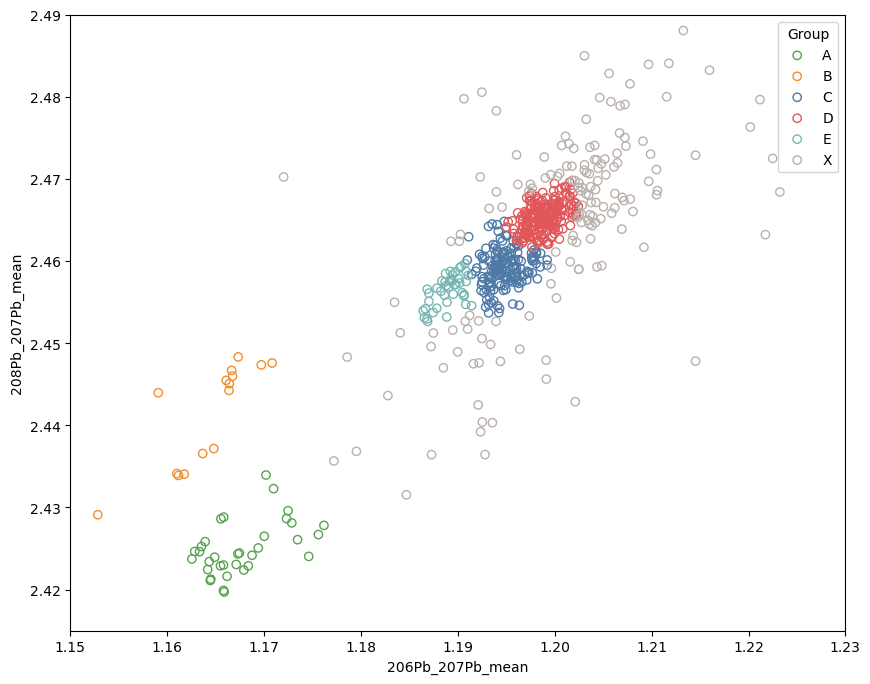

In [22]:
import matplotlib.pyplot as plt

custom_palette = {
    "A": "#59a14f",
    "B": "#f28e2b",
    "C": "#4e79a7",
    "D": "#e15759",
    "E": "#76b7b2",
    "X": "#bab0ac"
}

plt.figure(figsize=(10, 8))
for group, color in custom_palette.items():
    subset = full_data[full_data['group'] == group]
    plt.scatter(subset[xf], subset[yf], label=group, color=color, edgecolor=None, linewidth=1, marker='o', facecolors='none')

plt.xlim(1.15, 1.23)
plt.ylim(2.415, 2.49)
plt.xlabel(xf)
plt.ylabel(yf)
plt.legend(title='Group')
plt.show()


In [14]:
tbl_groups = (
    full_data.copy()
    .groupby(["core_id", "lat", "lon", "group"])
    .agg({"group": "value_counts"})
    .rename({"group": "grains"}, axis=1)
    .unstack(fill_value=0)
    .add_prefix("group_", axis=1)
    .droplevel(0, axis=1)
    .reset_index()
)
tbl_groups.columns.name = None
tbl_groups

,core_id,lat,lon,group_A,group_B,group_C,group_D,group_E,group_X
0,DF62-22PC,-78.116700,-173.883300,0,0,2,15,0,27
1,DF83-14PC,-78.480000,-164.143330,5,6,6,3,1,13
2,DF83-28PC,-76.830000,-152.510000,0,8,0,2,1,7
3,JR104-BC364,-72.983300,-83.440000,0,0,4,4,9,5
4,JR104-BC369,-71.576700,-82.860000,0,0,14,10,3,9
5,JR104-GC360,-71.993300,-76.553300,0,0,0,31,0,2
6,JR104-GC366,-72.845000,-82.615000,0,0,8,2,9,7
7,JR141-BC407,-73.212650,-115.239800,0,0,6,11,2,3
8,JR141-BC412,-73.922940,-115.856960,0,0,0,10,0,3
9,JR141-BC420,-74.141610,-112.856620,0,0,1,4,0,4


In [15]:
# to transfer to R for Rb-Sr geochronology
full_data.loc[:, ["spot_id", "group"]].to_csv("data/Kfs_Pb_groups.csv", index=False)